In [1]:
%cd ../
import os
import cv2
import numpy as np
import paddle
import matplotlib.pyplot as plt
from PIL import Image
from paddleseg.transforms import Normalize, Compose
import paddle.nn.functional as F
import PIL
import time
paddle.set_device('cpu')

e:\code\git\PaddleSeg


Place(cpu)

In [62]:
from paddleseg.transforms import RandomBlur, RandomPaddingCrop, ResizeStepScaling, RandomDistort, Resize, RandomHorizontalFlip, RandomVerticalFlip
from paddleseg.transforms import Padding, RandomScaleAspect, ResizeByLong, ResizeByShort, ResizeRangeScaling
from paddleseg.transforms import RandomCenterCrop, RandomNoise, PaddingByAspectRatio, RandomRotation, RandomCenterCrop, ScalePadding, RandomAffine
from paddleseg.transforms import MyRGBToHSV, MyFrontNormalize

In [108]:
trans = Compose([
                # RandomHorizontalFlip(),
                # RandomVerticalFlip(),
                RandomRotation(max_rotation=90, im_padding_value=(178,190,140), label_padding_value=0),
                # RandomNoise(prob=0.2, max_sigma=30),
                # RandomDistort(brightness_range=0.3, contrast_range=0.4,
                #                saturation_range=0.4, hue_prob=0, sharpness_range=5),
                
                # RandomScaleAspect(min_scale=0.4, aspect_ratio=2),
                # Padding(target_size=(int(4384*1.2), int(2048*1.2)), im_padding_value=(0,0,0), label_padding_value=0),
                # RandomPaddingCrop(crop_size=(int(4384*0.8), int(2048*0.8)), im_padding_value=(0,0,0), label_padding_value=0),
                RandomCenterCrop(),
                # ScalePadding(target_size=(int(4384*0.8), int(2048*0.8)), im_padding_value=(0,0,0), label_padding_value=0),
                # MyRGBToHSV(),
                
                # RandomPaddingCrop(crop_size=[512,512]),
                # Padding(target_size=[1024,1024], im_padding_value=(0,0,0), label_padding_value=0),
                
                # RandomAffine(size=(1024,1024), im_padding_value=(0,0,0), label_padding_value=0),
                Resize(target_size=[1024,1024]),
                Normalize(mean = (0., 0., 0.), std = (1, 1, 1)),
                
                 ]
                , to_rgb = True)


处理耗时为： 0.15847396850585938
pre:  1.0
Tensor(shape=[1], dtype=float32, place=Place(cpu), stop_gradient=True,
       [1.])
[1, 3, 1024, 1024]
(1024, 1024)
1.0


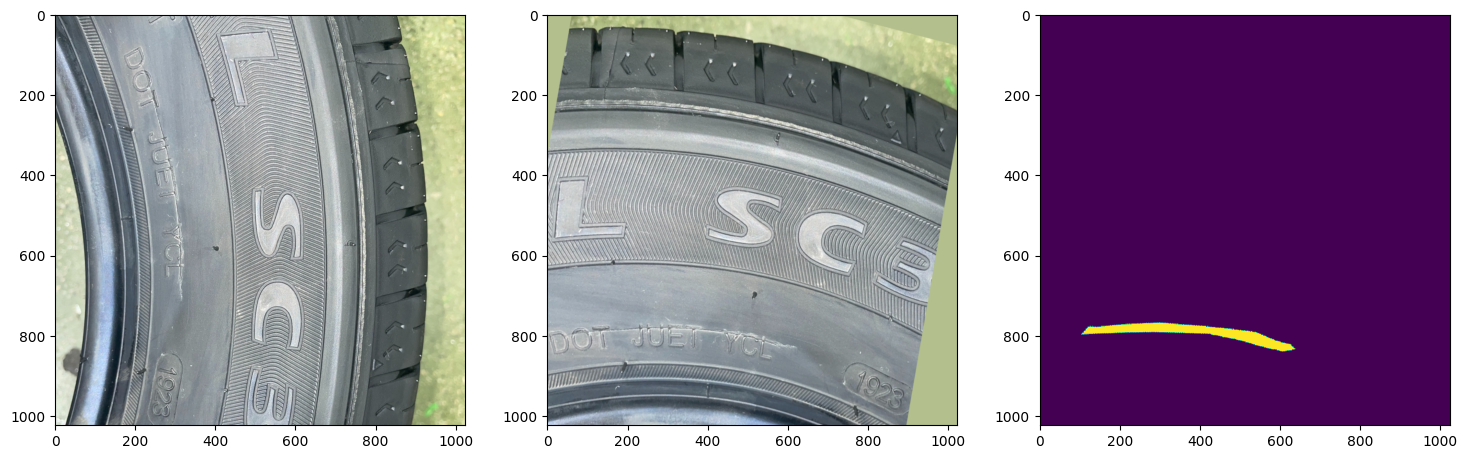

In [111]:
# im_path = r"C:\Users\hp\Desktop\tc_data\150x70\rust4x\imgs\143.jpg"
# label_path = r"C:\Users\hp\Desktop\tc_data\150x70\rust4x\gtFine\143.png"
# im_path = r"C:\Users\hp\Desktop\19_3.jpg"
im_path = r'C:\Users\hp\Desktop\before\2.jpg'
label_path = r'C:\Users\hp\Desktop\before\annotations\2.png'
data = {}
data['img'] = im_path
data['label'] = label_path
data['gt_fields'] = []
data['gt_fields'].append('label')
t1 = time.time()
data = trans(data)
print("处理耗时为：", time.time()-t1)
data['img'] = data['img'][np.newaxis, ...]
print("pre: ",data['img'].max() )
data['img'] = paddle.to_tensor(data['img'])
print(data['img'].max() )
print(data['img'].shape)
print(data['label'].shape)

img_b = data['img'][0].numpy()
img_b = np.transpose(img_b, [1,2,0])

# img_b = (img_b-img_b.min())/(img_b.max()-img_b.min())
print(img_b.max())
plt.figure(figsize=(18,9))
plt.subplot(1,3,1)
plt.imshow(np.array(Image.open(im_path)))
plt.subplot(1,3,2)
if img_b.shape[2]==1:
    img_b = img_b[:,:,0]
    plt.imshow(img_b, cmap='gray')
else:
    plt.imshow(img_b)
label = data['label']
plt.subplot(1,3,3)
plt.imshow(label)

In [ ]:
plt.imshow(img_b[:,:,2 ], cmap='gray')